# Портфель инициатив: запрос текстом — отчёт с графиками

**Управленческий вопрос.** Когда портфель инициатив выходит в плюс и какие
инициативы тянут его назад?

Здесь не пишут SQL. Запрос формулируется словами, а ассистент сам ходит в базу,
строит графики и собирает короткий отчёт. Важно другое: каждый его вывод
опирается на выполненный запрос, а не на память модели — поэтому ответ можно
проверить.

**Паспорт инициативы** — четыре параметра, по которым инициатива превращается
в кривую NPV: месяц старта, расходы, число месяцев до выхода на прибыльность и
число месяцев до окупаемости. Одинаковая методика этих четырёх параметров делает
инициативы сравнимыми, а кривые — складываемыми в кривую портфеля.

In [1]:
import sys
sys.path.append("..")
from tools.report_agent import отчёт

## Запрос первый: когда портфель выходит в плюс

Обратите внимание на строки «шаг 1», «шаг 2» — это реальные обращения ассистента
к базе и построение графика. Ниже — его отчёт.

Запрос: Покажи кривую накопленного NPV портфеля по месяцам и скажи, в каком месяце портфель выходит в плюс



  шаг 1: run_sql(query=…)
     строк получено: 37


  шаг 2: make_chart(kind=…, query=…, title=…, x=…, y=…)


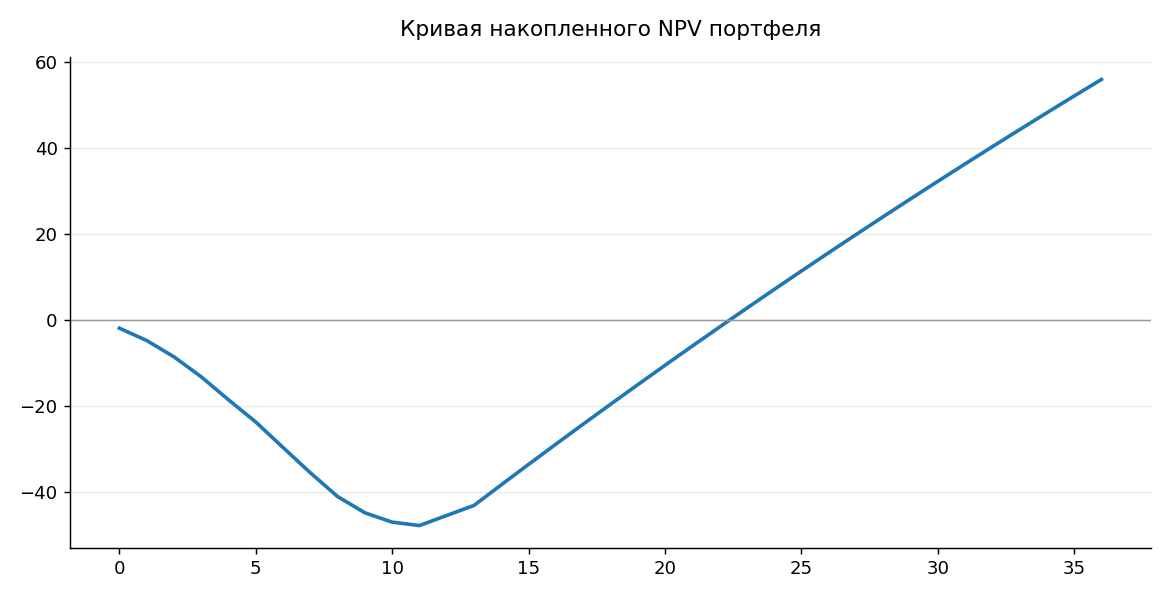

На графике видна динамика накопленного NPV портфеля. Портфель переходит точку безубыточности в 23-м месяце после старта. До этого момента наблюдается отрицательная динамика, связанная с первоначальными инвестициями и расходами. После 23-го месяца начинается устойчивый рост показателя, свидетельствующий о положительном эффекте реализуемых инициатив.

Рекомендация: продолжать реализацию текущих инициатив, так как их совокупное влияние приводит к росту стоимости бизнеса.

In [2]:
отчёт("Покажи кривую накопленного NPV портфеля по месяцам и скажи, в каком месяце портфель выходит в плюс")

## Запрос второй: какие инициативы окупаются позже всех

Запрос: Сравни инициативы по месяцу окупаемости от начала портфеля (месяц старта плюс месяцев до окупаемости) и покажи столбчатой диаграммой три самые поздние



  шаг 1: run_sql(query=…)
     строк получено: 3


  шаг 2: make_chart(kind=…, query=…, title=…, x=…, y=…)


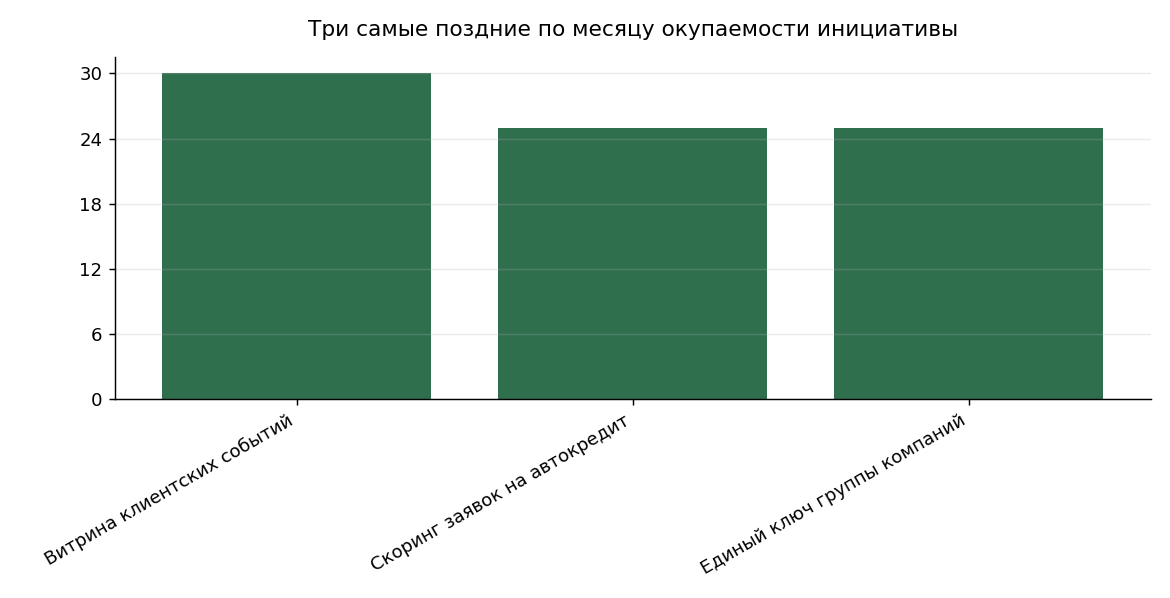

На графике показаны три инициативы с самым долгим сроком окупаемости. Самая поздняя — "Витрина клиентских событий", она окупится на 30-й месяц после старта портфеля. Следующие две — "Скоринг заявок на автокредит" и "Единый ключ группы компаний" — обе выходят на окупаемость на 25-м месяце. 

Рекомендуется обратить внимание на причины такой длительной окупаемости этих проектов и рассмотреть возможность оптимизации их реализации или пересмотра ожиданий по доходности.

In [3]:
отчёт("Сравни инициативы по месяцу окупаемости от начала портфеля (месяц старта плюс месяцев до окупаемости) и покажи столбчатой диаграммой три самые поздние")

## Запрос третий: куда уходят деньги

Запрос: Посчитай суммарные расходы по направлениям и покажи столбчатой диаграммой, где вложения самые большие



  шаг 1: run_sql(query=…)
     строк получено: 5


  шаг 2: make_chart(kind=…, query=…, title=…, x=…, y=…)


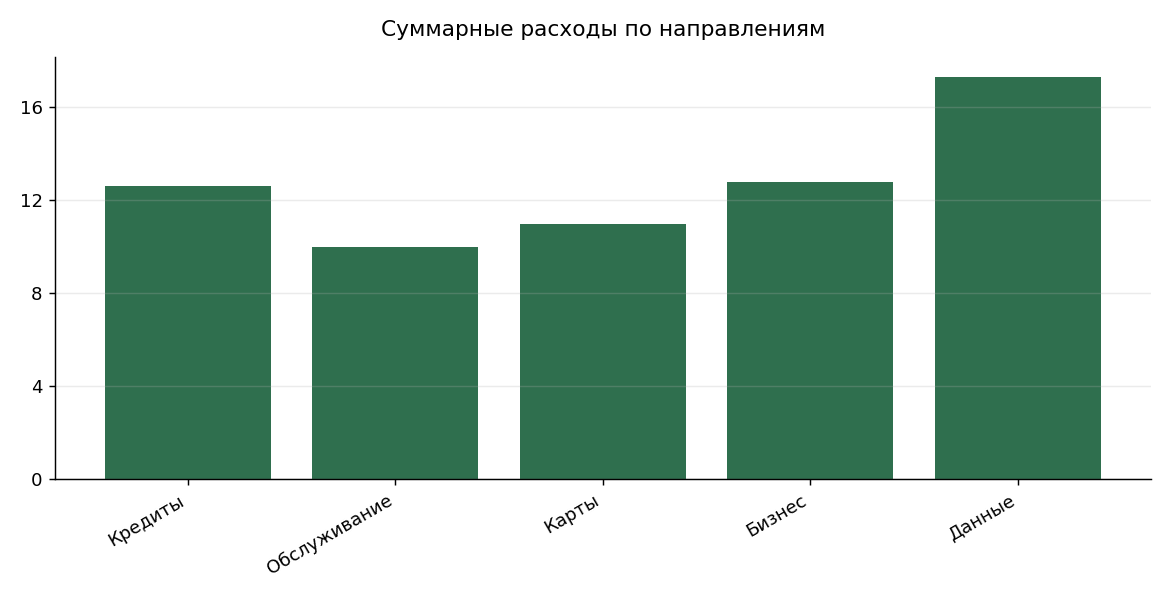

Наибольшие расходы у нас в направлении "Данные" — почти 17 млн рублей. Далее идут кредиты и бизнес примерно по 12–13 млн каждый. Наименьшие затраты — обслуживание, около 10 млн рублей. 

Смотри подробный расклад на графике выше.

In [4]:
отчёт("Посчитай суммарные расходы по направлениям и покажи столбчатой диаграммой, где вложения самые большие")

## Как принимать такой отчёт

Ассистент отвечает уверенно всегда — и когда прав, и когда ошибся. Три проверки
занимают минуту и снимают большую часть риска:

1. **Сходится ли число с запросом.** Каждый шаг агента — это SQL, который можно
   выполнить самому. Если число в тексте не выводится из запроса, ему верить нельзя.
2. **Тот ли период и тот ли срез.** Частая ошибка — ответ посчитан по всем месяцам,
   когда спрашивали про горизонт наблюдения, или по всем инициативам, когда речь
   шла об одном направлении.
3. **Отличает ли агент план от факта.** В базе есть и плановая кривая из паспорта,
   и фактические расходы по месяцам. Вопрос «сколько потратили» и вопрос «сколько
   собирались потратить» дают разные числа.

Проверить любой шаг можно тем же запросом в тетради конвейера или прямо в базе.

## Задание

Сформулируйте свой вопрос к портфелю — так, как задали бы его аналитику словами,
без SQL. Например: «какие инициативы к концу горизонта не выходят в плюс» или
«как изменится кривая портфеля, если самая дорогая инициатива стартует на три
месяца позже». Прогоните его через `отчёт(...)` и проверьте ответ по трём пунктам
выше.